<a href="https://colab.research.google.com/github/zelal-Eizaldeen/deeplearning_course/blob/main/1_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoRA -


Updating all parameters of a model has a large potential of increasing its performance but comes with several disadvantages. It is costly to train, has slow training times, and requires significant storage. To resolve these issues, attention has been given to **parameter-efficient fine-tuning (PEFT)** alternatives that focus on fine-tuning pretrained models at higher computational efficiency.

Fine-tuning such large models is potentially very expensive.

In classical fine-tuning, the idea is to **fit the weights of a model for a task or a new domain**.

we need a method that **allows us to have efficient and low-cost fine-tuning** and preferentially **keeping the model weights frozen**.


The **rank hypothesis** suggests that we **can capture significant changes that occur in a neural network using a lower-dimensional representation**.

In the case of fine-tuning, the model weights after fine-tuning can be defined in this way:



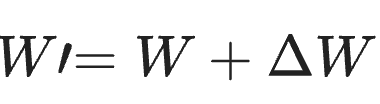

 ∆W: represents the update of the weights during fine-tuning.

For the **rank hypothesis**, not all of these elements of ∆W are important, and instead, **we can represent it as the product of two matrices with small dimensions A and B (low-rank matrices)**.

So, in this case, **the model weights remain frozen, but we just need to train these two matrices:**

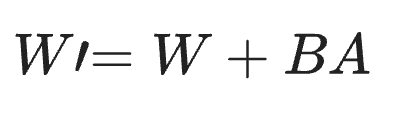

a matrix (especially larger ones) **contains a lot of redundant information**. A matrix can be reduced into a **set of linearly independent vectors** (the number of linearly independent vectors needed to define a matrix is called a **rank**

The idea is to **find two matrices that have a smaller rank than the original one and that multiplied with each other give us the same matrix update weights as if we had done fine-tuning**.
 This process is called **Low-Rank Adaptation (LoRA)**.

Recall ->  The weight matrices of an LLM have a lot of **linear dependence**, **there is a lot of redundant information**

This figure compares the classical fine tuning vs LoRA

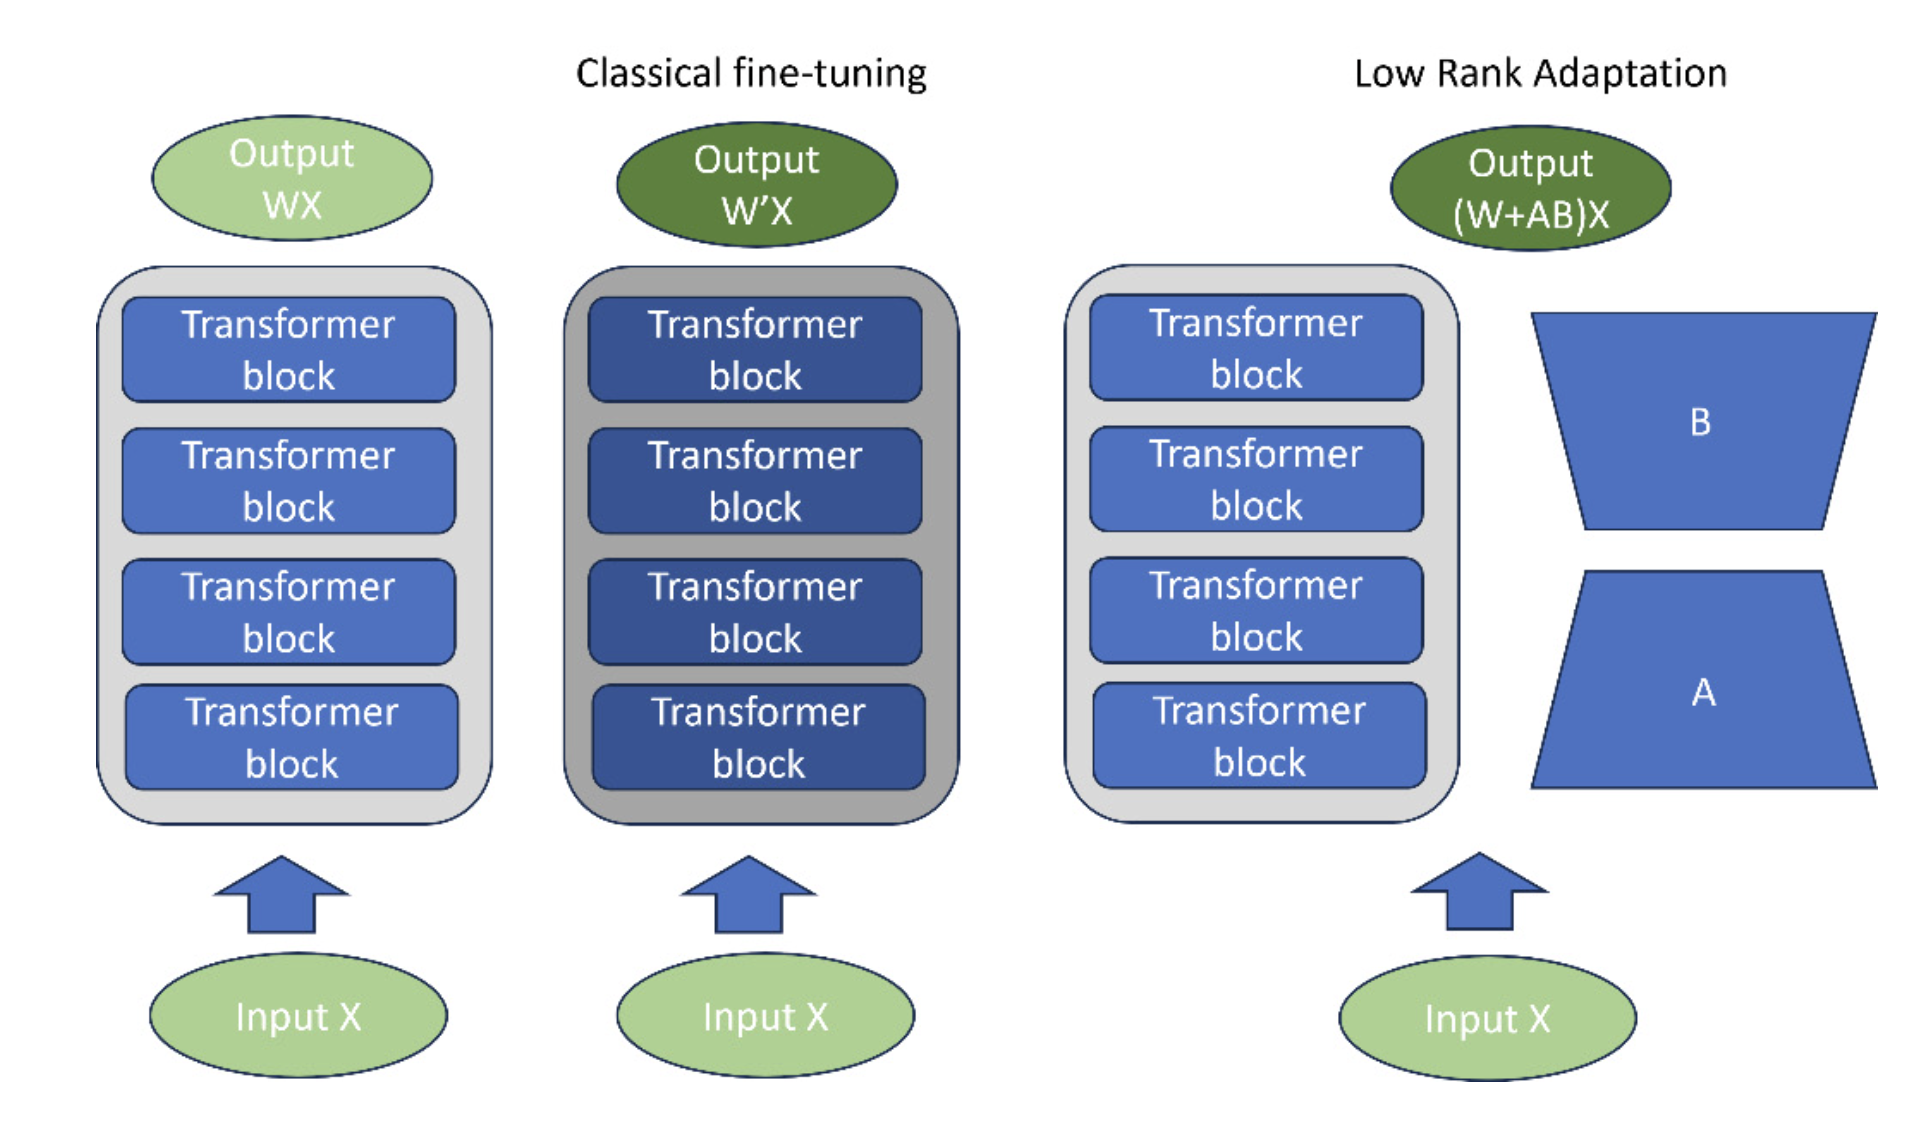

# LoRA

LoRA is a PEFT technique that only **requires updating a small set of parameters.**. It creates ***a small subset of the base model to fine-tune*** instead **of adding layers to the model** (like in adapters technique)

This subset allows for much quicker fine-tuning since we only need to update a small part of the base model

In LoRA,
- We keep the original weights of the LLM **frozen**.
- We then create **two matrices (A and B)** that, when multiplied together, will have the same dimensions as the model’s weight matrices (W).
- During fine-tuning, we pass the **input X for the frozen model** **and the change matrix (the product AB)** and ***get the output***.
- With this output, **we calculate the loss**, and using this loss, **we update the matrices A and B** (via classical backpropagation).
- We continue this process until we are satisfied with the result

This figure shows the Different-ranked matrices to obtain the change weight matrix

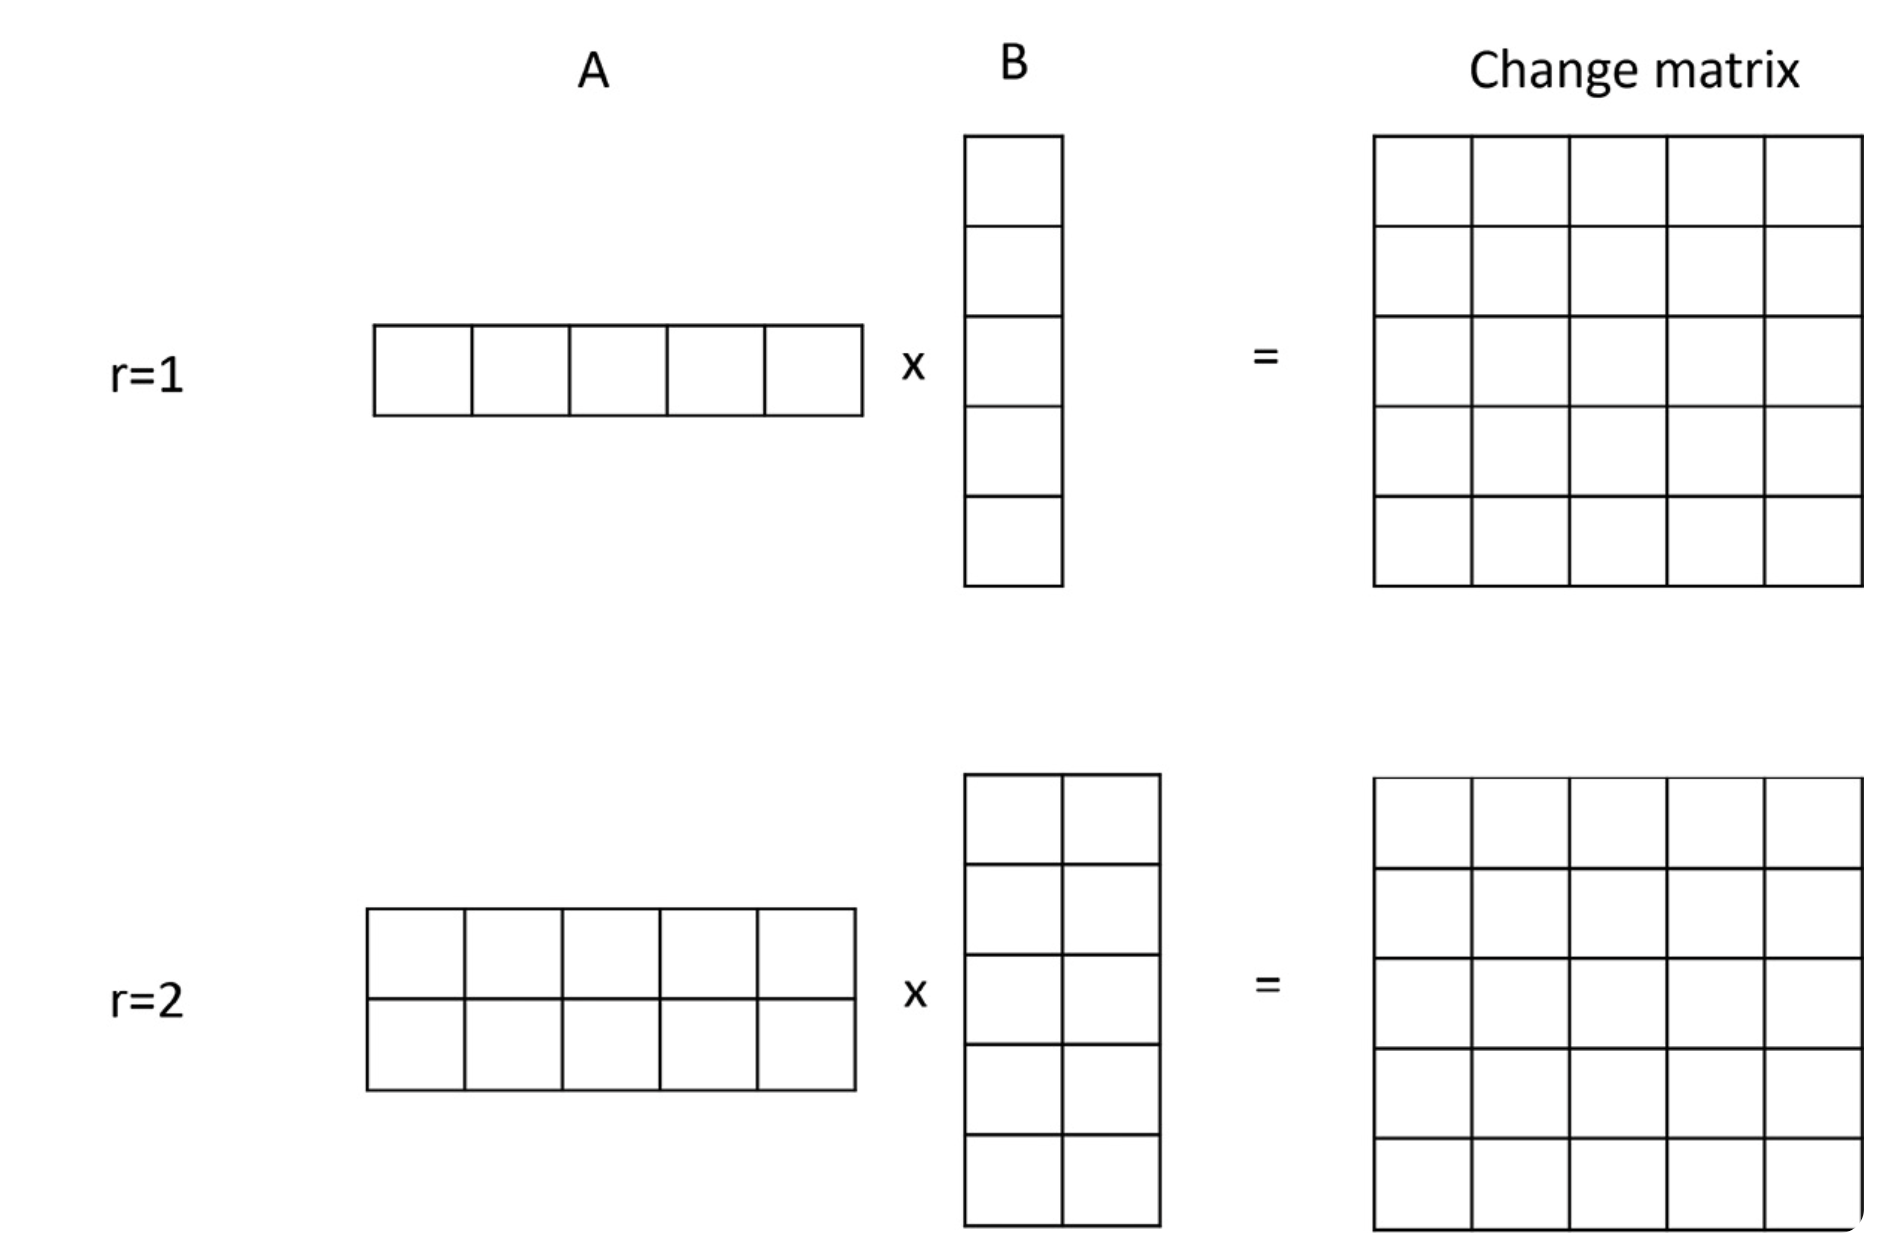

In LoRA, we have **a hyper-parameter r** describing **the depth of the A and B matrices**. The greater the r value, the greater the amount of information these matrices have (but also a greater number of parameters and thus computational cost)

The results show that **even low-rank** matrices perform quite well.

# Why LoRA? Advantages?
- It is **efficient in training** (for GPT-3, a model of 175 billion parameters can be used efficiently by LoRA by training only 17.5 million parameters).
- In **inference**, it does not increase the computational cost (it is an addition where **we add the change matrix** to the original model weights).
- LoRA will not alter the original capabilities of the model, and it **reduces the memory cost** associated with saving checkpoints during fine-tuning.
- We can create different change matrices for different applications and domains.

# compressing the model for (more) efficient training
We can make LoRA even more efficient by reducing the memory requirements of the model’s original weights before projecting them into smaller matrices

The weights of an LLM are numeric values with a given **precision**, **which can be expressed by the number of bits like float64 or float32**.




This figure represents pi with float 32-bit and float 16-bit. If we lower the amount of bits to represent a value, we get a **less accurate result**. However, if we lower the number of bits we also **lower the memory requirements** of that model.

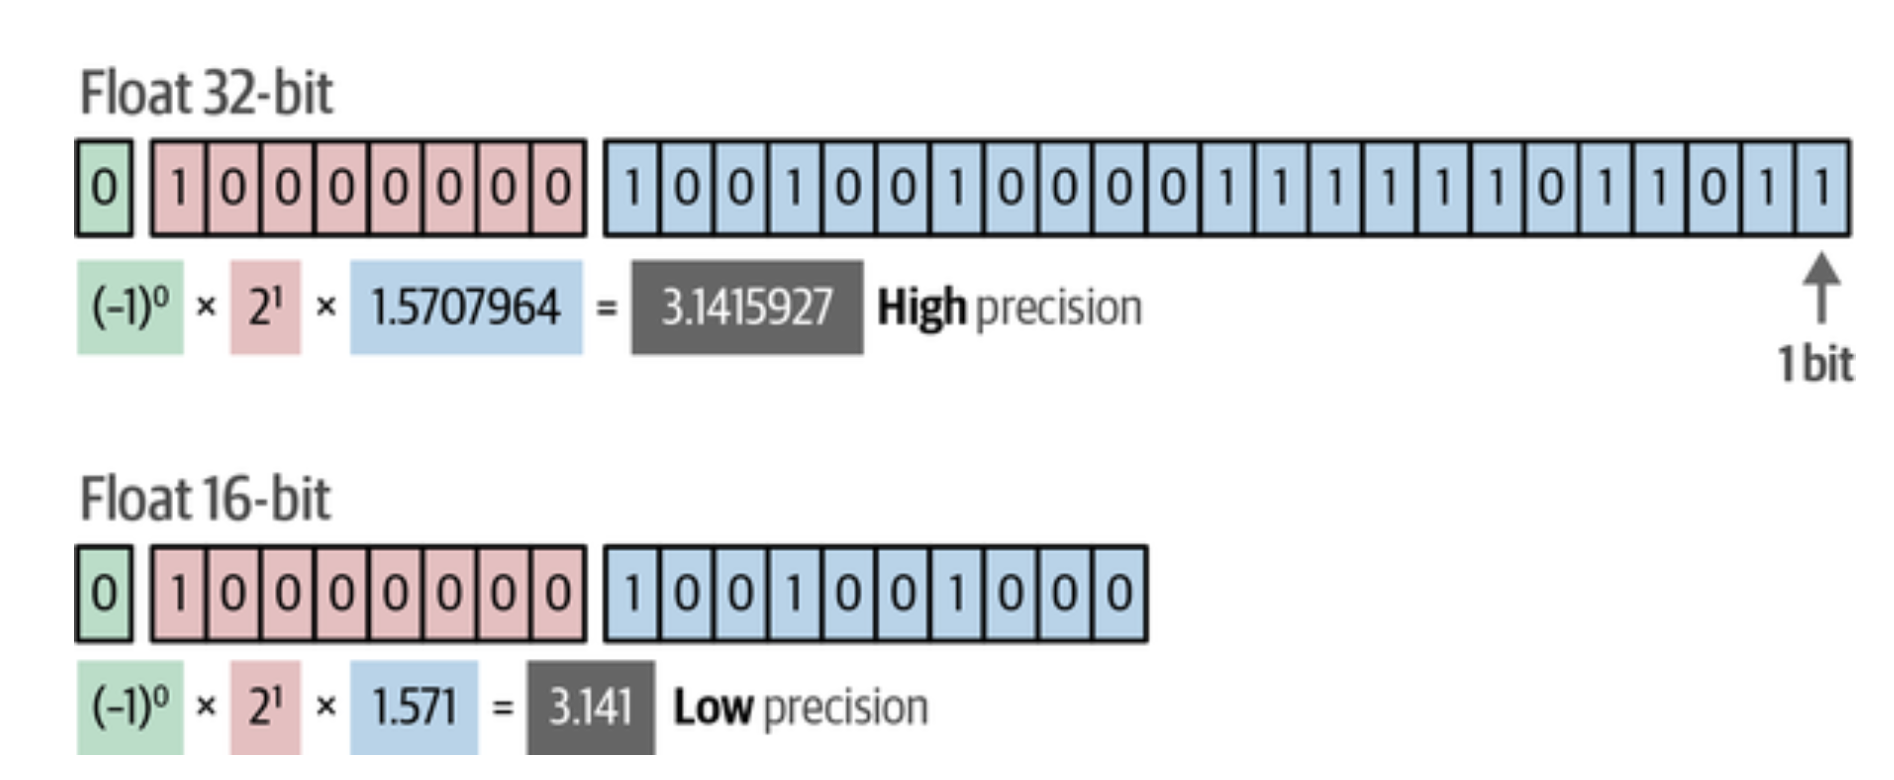

With **quantization**, we aim to lower the number of bits while still accurately representing the original weight values

# Example
Let's put that knowledge into practice!
we will fine-tune a completely open source and smaller version of Llama, **[TinyLlama](https://huggingface.co/TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T)**, to follow instructions using the **QLoRA** procedure.

Consider this model **a base or pretrained model**, one that was trained with language modeling but cannot yet follow instructions.

# Step 1: Templating Instruction Data
To have the LLM follow instructions, we will need to **prepare instruction data** that follows a chat template. This figure shows this chat template, which **differentiates between what the LLM has generated and what the user has generated.**

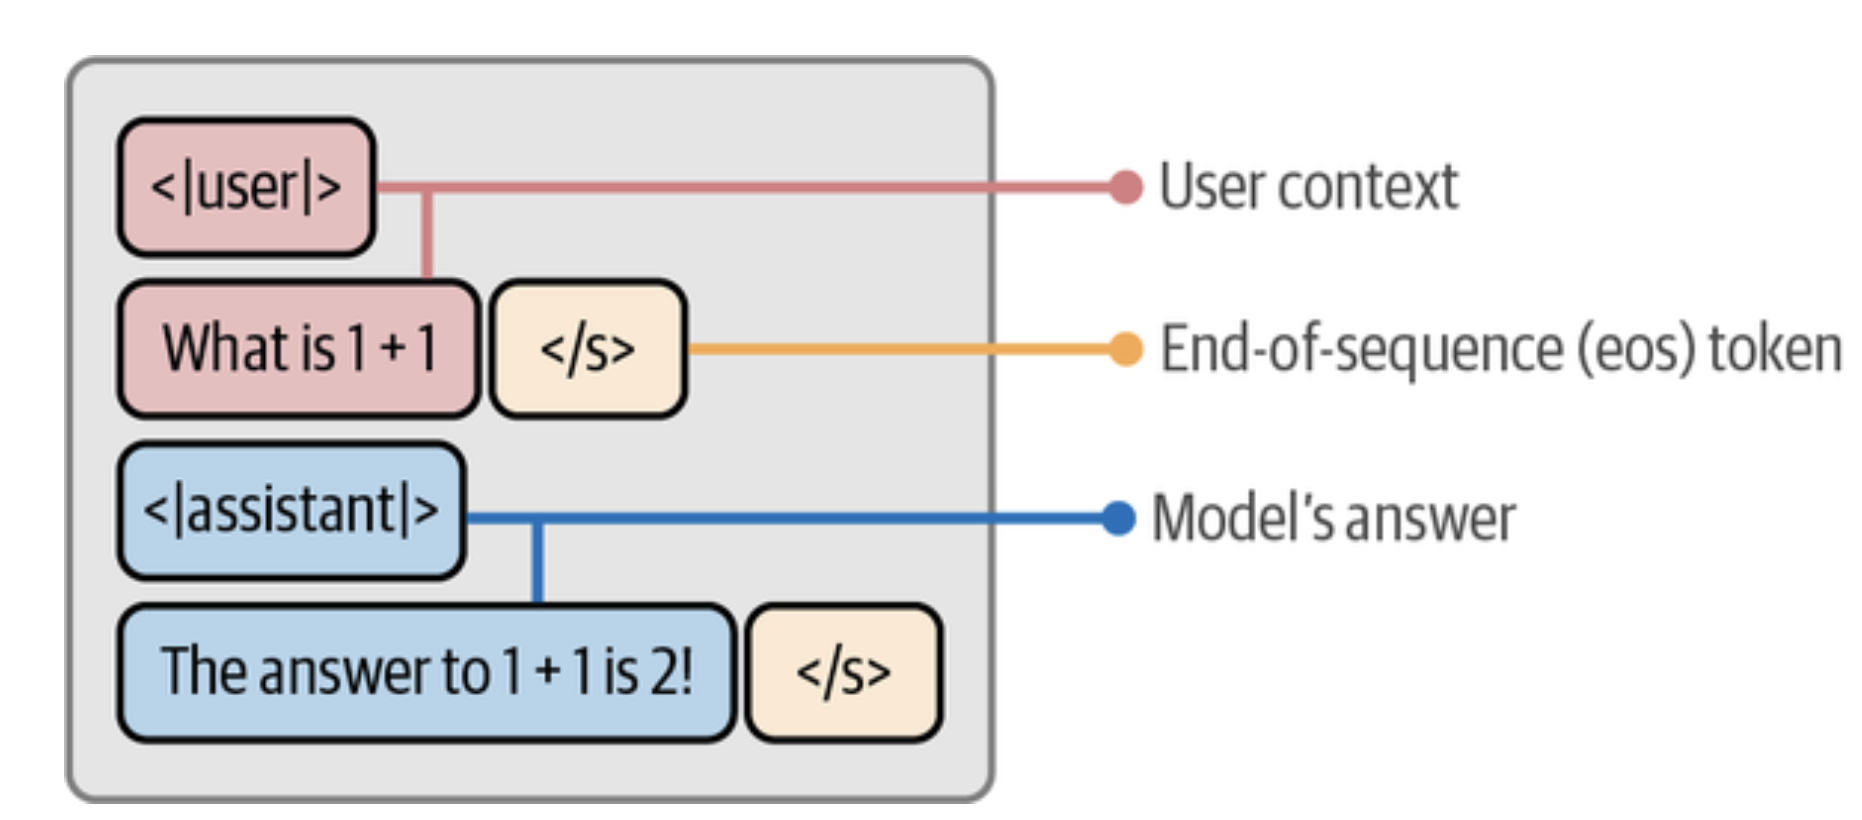

# Dependencies

In [ ]:
!pip install -q accelerate==0.31.0 peft==0.11.1 bitsandbytes==0.43.1 transformers==4.41.2 trl==0.9.4 sentencepiece==0.2.0 triton==3.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.7/226.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.

# Data Preprocessing

We chose this chat template to use in the example since the chat version of **TinyLlama** uses the same format.

The **data** that we are using is a small subset of the **[UltraChat dataset](https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k)**. This dataset is a filtered version of the original UltraChat dataset that contains almost 200k conversations between a user and an LLM.

In [ ]:
from transformers import AutoTokenizer
from datasets import load_dataset


We create a function, format_prompt, to make sure that the conversations follow this template:

We select a subset of 3,000 documents to reduce the training time, but you can increase this value to get more accurate results.



In [ ]:
# Load a tokenizer to use its chat template
template_tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

def format_prompt(example):
    """Format the prompt to using the <|user|> template TinyLLama is using"""

    # Format answers
    chat = example["messages"]
    prompt = template_tokenizer.apply_chat_template(chat, tokenize=False)

    return {"text": prompt}

# Load and format the data using the template TinyLLama is using
dataset = (
    load_dataset("HuggingFaceH4/ultrachat_200k",  split="test_sft")
      .shuffle(seed=42)
      .select(range(3_000))
)
dataset = dataset.map(format_prompt)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

Generating train_sft split:   0%|          | 0/207865 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/23110 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Using the "text" column, we can explore these formatted prompts:



In [ ]:
# Example of formatted prompt
print(dataset["text"][2576])

<|user|>
Given the text: Knock, knock. Who’s there? Hike.
Can you continue the joke based on the given text material "Knock, knock. Who’s there? Hike"?</s>
<|assistant|>
Sure! Knock, knock. Who's there? Hike. Hike who? Hike up your pants, it's cold outside!</s>
<|user|>
Can you tell me another knock-knock joke based on the same text material "Knock, knock. Who's there? Hike"?</s>
<|assistant|>
Of course! Knock, knock. Who's there? Hike. Hike who? Hike your way over here and let's go for a walk!</s>



# Model Quantization
Now that we have our data, we can start **loading in our model**. This is where we apply the Q in **QLoRA**, namely quantization.

We use the **bitsandbytes** package to compress the pretrained model to a 4-bit representation

In BitsAndBytesConfig, you can define the quantization scheme. We follow the steps used in the original QLoRA paper and load the model in 4-bit (load_in_4bit) with a normalized float representation (bnb_4bit_quant_type) and double quantization (bnb_4bit_use_double_quant):

In [ ]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 14.1 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

# 4-bit quantization configuration - Q in QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Use 4-bit precision model loading
    bnb_4bit_quant_type="nf4",  # Quantization type
    bnb_4bit_compute_dtype="float16",  # Compute dtype
    bnb_4bit_use_double_quant=True,  # Apply nested quantization
)

# Load the model to train on the GPU
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",

    # Leave this out for regular SFT
    quantization_config=bnb_config,
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=False)
tokenizer.pad_token = "<PAD>"
tokenizer.padding_side = "left"

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

This **quantization procedure** allows us to decrease the size of the original model while retaining most of the original weights’ precision

# LoRA Configuration

Now, we will define our LoRA configuration using the **peft** library, which **represents hyperparameters of the fine-tuning process**:

In [ ]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

# Prepare LoRA Configuration
peft_config = LoraConfig(
    lora_alpha=32,  # LoRA Scaling
    lora_dropout=0.1,  # Dropout for LoRA Layers
    r=64,  # Rank
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=  # Layers to target
     ['k_proj', 'gate_proj', 'v_proj', 'up_proj', 'q_proj', 'o_proj', 'down_proj']
)

# prepare model for training
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

# Training Configuration
we need to configure our training parameters
- num_train_epochs: The total number of training rounds. Higher values tend to degrade performance so we generally like to keep this low.
- learning_rate: Determines the step size at each iteration of weight updates. The authors of QLoRA found that higher learning rates work better for larger models (>33B parameters).
- lr_scheduler_type: A cosine-based scheduler to adjust the learning rate dynamically. It will linearly increase the learning rate, starting from zero, until it reaches the set value. After that, the learning rate is decayed following the values of a cosine function.
- optim: The paged optimizers used in the original QLoRA paper.

Optimizing these parameters is a difficult task and there are no set guidelines for doing so. It requires experimentation to figure out what works best for specific datasets, model sizes, and target tasks.

In [ ]:
from transformers import TrainingArguments

output_dir = "./results"

# Training arguments
training_arguments = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=1,
    logging_steps=10,
    fp16=True,
    gradient_checkpointing=True
)

# Training
Now that we have prepared all our models and parameters, we can start fine-tuning our model. We load in SFTTrainer and simply run trainer.train():

In [ ]:
from trl import SFTTrainer

# Set supervised fine-tuning parameters
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    dataset_text_field="text",
    tokenizer=tokenizer,
    args=training_arguments,
    max_seq_length=512,

    # Leave this out for regular SFT
    peft_config=peft_config,
)

# Train model
trainer.train()

# Save QLoRA weights
trainer.model.save_pretrained("TinyLlama-1.1B-qlora")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1965: FutureWarning: `--push_to_hub_token` is deprecated and will be removed in version 5 of 🤗 Transformers. Use `--hub_token` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:269: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:307: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:397: UserWarning: You passed a tokenizer with `padding_side` not equal to `right` to the SFTTrainer. This might lead to some unexpected behaviour due to overflow issues when training a model in half-precision. You might consider adding `tokenizer.padding_side = 'right'` to your code.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zelalezaldeen (zelalezaldeen-uiuc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,1.670500
20,1.476200
30,1.451000
40,1.488300
50,1.477900
60,1.390800
70,1.495200
80,1.450300
90,1.427600
100,1.404100


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# Merge Weights
After we have trained our QLoRA weights, we still need to **combine them with the original weights to use them**. We reload the model in 16 bits, instead of the quantized 4 bits, to merge the weights. Although the tokenizer was not updated during training, we save it to the same folder as the model for easier access:

In [ ]:
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    "TinyLlama-1.1B-qlora",
    low_cpu_mem_usage=True,
    device_map="auto",
)

# Merge LoRA and base model
merged_model = model.merge_and_unload()

After merging the adapter with the base model, we can use it with the prompt template that we defined earlier:

In [ ]:
from transformers import pipeline

# Use our predefined prompt template
prompt = """<|user|>
Tell me something about Large Language Models.</s>
<|assistant|>
"""

# Run our instruction-tuned model
pipe = pipeline(task="text-generation", model=merged_model, tokenizer=tokenizer)
print(pipe(prompt)[0]["generated_text"])

<|user|>
Tell me something about Large Language Models.</s>
<|assistant|>
Large Language Models (LLMs) are a type of artificial intelligence (AI) that can generate human-like language. They are trained on large amounts of data, including text, audio, and video, and are capable of generating complex sentences and phrases that are often difficult to create by humans.

LLMs are used in a variety of applications, including natural language processing (NLP), machine translation, and chatbots. They can be used to generate text in different languages, such as English, French, or Chinese, and can also be used to generate images, videos, or other forms of media.

One of the most significant applications of LLMs is in the field of natural language generation (NLG). NLG is the process of generating human-like language from a computer program. LLMs can be used to generate text in a variety of fields, including marketing, finance, and medicine.

Another application of LLMs is in the field of chatbo

The aggregate output shows that the model now closely follows our instructions, which is not possible with the base model.

# Reference
Building AI Agents with LLMs, RAG, and Knowledge Graphs Book


Hands-On Large Language Models Book


# LORA

**post-training** involves smaller datasets and generally focuses on narrower domains of knowledge and ranges of behavior. It seems wasteful to use a terabit of weights to represent updates from a gigabit or megabit of training data. This intuition has motivated **parameter efficient fine-tuning (PEFT)**, which **adjusts a large network by updating a much smaller set of parameters.**

The leading PEFT method is low-rank adaptation, or LoRA. LoRA replaces each weight matrix W from the original model with a modified version

W′=W+γBA,

where **B and A are matrices that together have far fewer parameters than W**, and
**γ is a constant scaling factor**.

In effect, **LoRA creates a low-dimensional representation of the updates** imparted by fine-tuning.

# Why LORA>

LoRA may offer a**dvantages in the cost and speed of post-training**, and there are also a few operational reasons to prefer it to full fine-tuning (henceforth, FullFT):


# 1. - **Multi-tenant serving**.
Since LoRA trains an adapter (i.e., the A and B matrices) while keeping the original weights unchanged, **a single inference server can keep many adapters** (different model versions) in memory and sample from them simultaneously in a batched way. Modern inference engines such as vLLM and SGLang implement this feature.

# Analogy ->
**One kitchen, many spice jars**:

**The base model is the kitchen** which has staple ingredients (rice, oil, pans). **LoRA adapters are small spice mixes**. With one kitchen you can cook many distinct dishes at once by sprinkling different spice mixes per plate. **No need to rebuild a whole new kitchen for each order**.

The heavy thing (kitchen = base model) is shared; the lightweight add-ons (spices = LoRA) **are cheap to store and quick to swap per request**, **so one server can handle many tenants at once efficiently.**


# 2. Layout size for training.
When fine-tuning the whole model, the optimizer state needs to be stored along with the original weights, often at higher precision. As a result, **FullFT usually requires an order of magnitude more accelerators than sampling from the same model does, and thus a different layout**.

Note that **for training**, besides storing the weights, we typically need to store gradients and optimizer moments for all of the weights; moreover, these variables are often stored in higher precision (float32) than what’s used to store the weights for inference (bfloat16 or lower).

 Since **LoRA trains far fewer weights and uses far less memory, it can be trained on a layout only slightly larger than what is used for sampling**. This makes training more accessible, and often more efficient.

# 3. Ease of loading and transfer:
With fewer weights to store, L**oRA adapters are fast and easy** to set up or transfer between machines.

These reasons **are sufficient to explain the growing popularity of LoRA since the publication of the original LoRA paper in 2021**.

 However, the literature is unclear on how well LoRA performs relative to FullFT.

# What matters for LoRA

We will cover a series of **supervised fine-tuning and reinforcement learning experiments** we conducted to determine the conditions under which LoRA matches FullFT efficiency. We **did a few things differently from previous experiments** on LoRA:


**In supervised learning**, we measured **log loss rather than employing sampling-based evals**, with the same goal of generality in mind.

 **Log loss** measurement gives clean results and scaling laws over ranges of training steps and training parameters.

# Add LoRA to DeepRetrieval



# Step1

 verl/utils/model.py

In [ ]:
def create_hf_actor_with_optional_lora(
    model_name: str,
    *,
    lora_rank: int = 0,
    lora_alpha: int = None,
    lora_dropout: float = 0.0,
    target_modules=None,
    automodel_kwargs=None,
):
    """
    Load a CausalLM from pretrained weights and (optionally) wrap it with LoRA.
    Return a torch.nn.Module ready to be FSDP-wrapped by the workers.
    """
    from transformers import AutoModelForCausalLM
    from peft import LoraConfig, get_peft_model

    if automodel_kwargs is None:
        automodel_kwargs = {}

    # sensible defaults
    if lora_alpha is None:
        lora_alpha = lora_rank
    if target_modules is None:
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

    # 1) load base
    base = AutoModelForCausalLM.from_pretrained(
        model_name,
        **{
            "local_files_only": True,
            "torch_dtype": torch.bfloat16,  # H200/A100 friendly default
            **automodel_kwargs,
        },
    )

    # 2) optional LoRA wrap
    if lora_rank and lora_rank > 0:
        lconf = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            bias="none",
            task_type="CAUSAL_LM",
            target_modules=target_modules,
        )
        base = get_peft_model(base, lconf)

    return base
# -----------------------------------------------------------------------------


# Step2
2) Call it from the worker before FSDP
In verl/workers/fsdp_workers.py (where the actor/policy is constructed), replace the current actor creation with:


/verl/workers/fsdp_workers.py

# notes
diff -
deepRetrieval - added this by Zilal


In [ ]:
from verl.utils.fsdp_utils import  collect_lora_params, layered_summon_lora_params, replace_lora_wrapper,\


2. inside utils-fsdp_utils
-

# 1) Wrap the actor with PEFT right after loading from HF and before FSDP

In ActorRolloutRefWorker._build_model_optimizer(...), you already do:

actor_module = AutoModelForCausalLM.from_pretrained(...)

👉 Insert the** PEFT block immediately after the from_pretrained(...)** and **before the FSDP wrap**:

In [ ]:
from peft import LoraConfig, get_peft_model  # add at top of file or inside the function

# --- PEFT (LoRA) OPTIONAL WRAP ---------------------------------
lora_rank = self.config.model.get('lora_rank', 0)
if lora_rank and lora_rank > 0:
    lora_cfg = LoraConfig(
        r=lora_rank,
        lora_alpha=self.config.model.get('lora_alpha', lora_rank),
        lora_dropout=self.config.model.get('lora_dropout', 0.05),
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=self.config.model.get(
            'target_modules',
            ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
        ),
    )
    actor_module = get_peft_model(actor_module, lora_cfg)
    # optional: print to verify only adapters are trainable
    try:
        actor_module.print_trainable_parameters()
    except Exception:
        pass
# ---------------------------------------------------------------


After that, your existing FSDP code continues unchanged:

In [ ]:
actor_module_fsdp = FSDP(actor_module, ...)


This guarantees PEFT → FSDP order.

# 2) Save adapters correctly when checkpointing the actor

n ActorRolloutRefWorker.save_checkpoint(...) you currently do:

In [ ]:
with FSDP.state_dict_type(...):
    state_dict = self.actor.actor_module.state_dict()
...
self.actor_module.save_pretrained(local_path, state_dict=state_dict)


For LoRA, you want to **save adapters only**. Patch that block like this:

In [ ]:
with FSDP.state_dict_type(self.actor.actor_module, StateDictType.FULL_STATE_DICT, cfg):
    state_dict = self.actor.actor_module.state_dict()

if self.rank == 0:
    print(f'Saving actor checkpoint to {local_path}')
    os.makedirs(local_path, exist_ok=True)

    # If PEFT is active, save adapters; else save full weights
    if hasattr(self.actor_module, "peft_config"):
        # PEFT wrapper knows how to save its adapters
        self.actor_module.save_pretrained(local_path)
    else:
        self.actor_module.save_pretrained(local_path, state_dict=state_dict)

    self.tokenizer.save_pretrained(local_path)
    ...


**Config: add LoRA knobs to your YAML**

Add these under the same model: block this worker reads (not actor_rollout_ref.model, because this worker uses self.config.model.*):

**code/verl/trainer/config/ppo_trainer.yaml**

In [ ]:
#  actor_rollout_ref:
#   hybrid_engine: True
#   model:
#     path: ~/models/deepseek-llm-7b-chat
#     external_lib: null
#     override_config: { }
#     enable_gradient_checkpointing: False
#     use_remove_padding: False

 # ↓ Add these LoRA knobs
    lora_rank: 32          # 0 disables LoRA
    lora_alpha: 32
    lora_dropout: 0.05
    target_modules: ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]

**Optional (cleaner via overlay)**

Create verl/config/lora_enable.yaml:

In [ ]:
actor_rollout_ref:
  model:
    lora_rank: 32
    lora_alpha: 32
    lora_dropout: 0.05
    target_modules: ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]


In [ ]:
python -m verl.trainer.ppo.main_ppo \
  -c verl/config/ppo_trainer.yaml \
  -c verl/config/lora_enable.yaml
